In [1]:
%pip install transformers torch pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [3]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np

In [4]:
processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Base-hf")
model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Base-hf")
model.eval()

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

DepthAnythingForDepthEstimation(
  (backbone): Dinov2Backbone(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_

In [5]:
image = Image.open("test_image.png")

In [6]:
inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    depth = outputs.predicted_depth


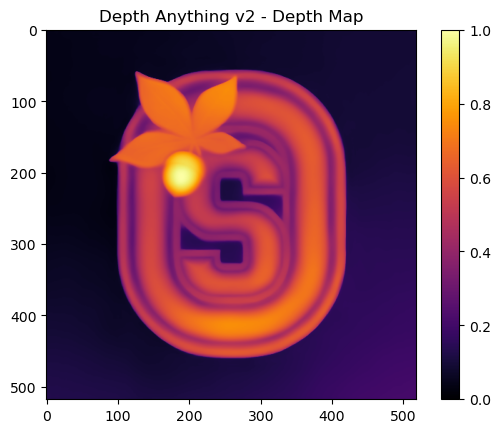

In [7]:
depth_normalized = (depth - depth.min()) / (depth.max() - depth.min())
plt.imshow(depth_normalized.squeeze().numpy(), cmap='inferno')
plt.colorbar()
plt.title("Depth Anything v2 - Depth Map")
plt.show()

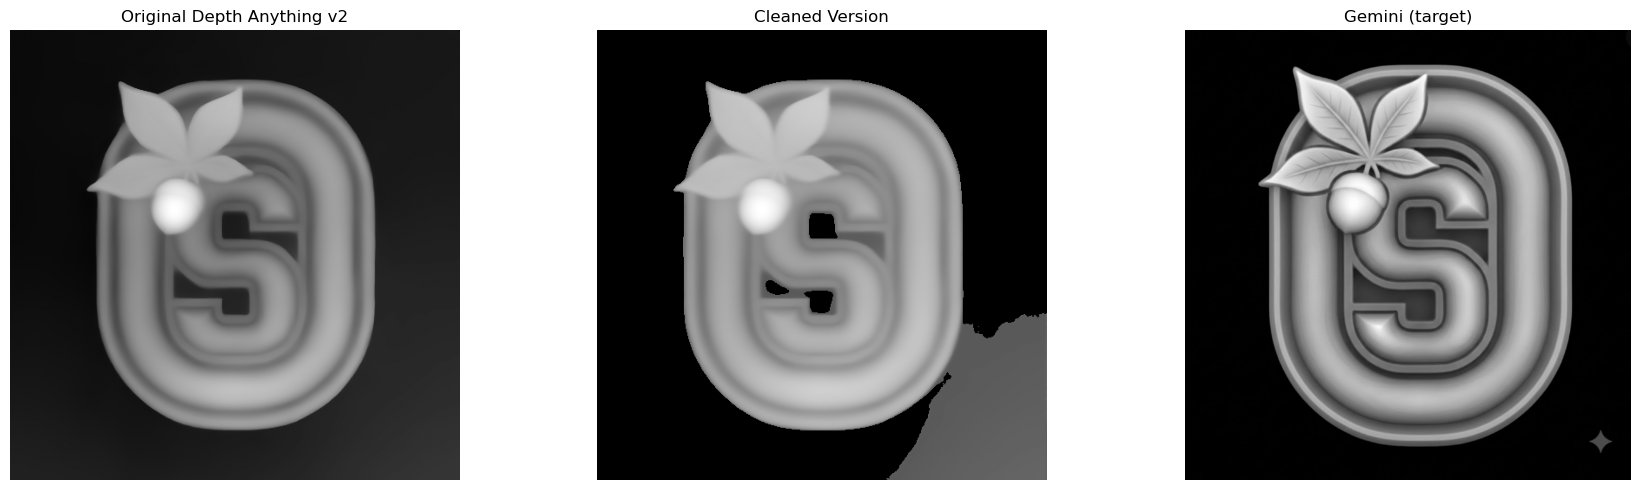

Saved cleaned depth map.


In [11]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Your existing depth output (normalized 0-1)
depth = depth_normalized.squeeze().numpy()
# Step 1: Threshold background to pure black
# Anything below 15% of max = background
threshold = 0.15
depth_clean = depth.copy()
depth_clean[depth_clean < threshold] = 0

# Step 2: Smooth the subject slightly (remove noise, keep edges)
from scipy.ndimage import gaussian_filter
# Only smooth the non-zero areas
mask = depth_clean > 0
depth_smooth = depth_clean.copy()
depth_smooth[mask] = gaussian_filter(depth_clean[mask], sigma=1.5)

# Step 3: Normalize subject back to full range
subject_pixels = depth_smooth[mask]
if len(subject_pixels) > 0:
    subject_min = subject_pixels.min()
    subject_max = subject_pixels.max()
    depth_smooth[mask] = (depth_smooth[mask] - subject_min) / (subject_max - subject_min)
    # Ensure edges start at 35% gray like Gemini
    depth_smooth[mask] = 0.35 + depth_smooth[mask] * 0.65

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(depth, cmap='gray')
axes[0].set_title("Original Depth Anything v2")
axes[0].axis('off')

axes[1].imshow(depth_smooth, cmap='gray')
axes[1].set_title("Cleaned Version")
axes[1].axis('off')

# Compare with Gemini
gemini = Image.open("gemini_output.png").convert("L")
axes[2].imshow(gemini, cmap='gray')
axes[2].set_title("Gemini (target)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save
result = Image.fromarray((depth_smooth * 255).astype('uint8'))
result.save("depth_anything_cleaned.png")
print("Saved cleaned depth map.")

In [12]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


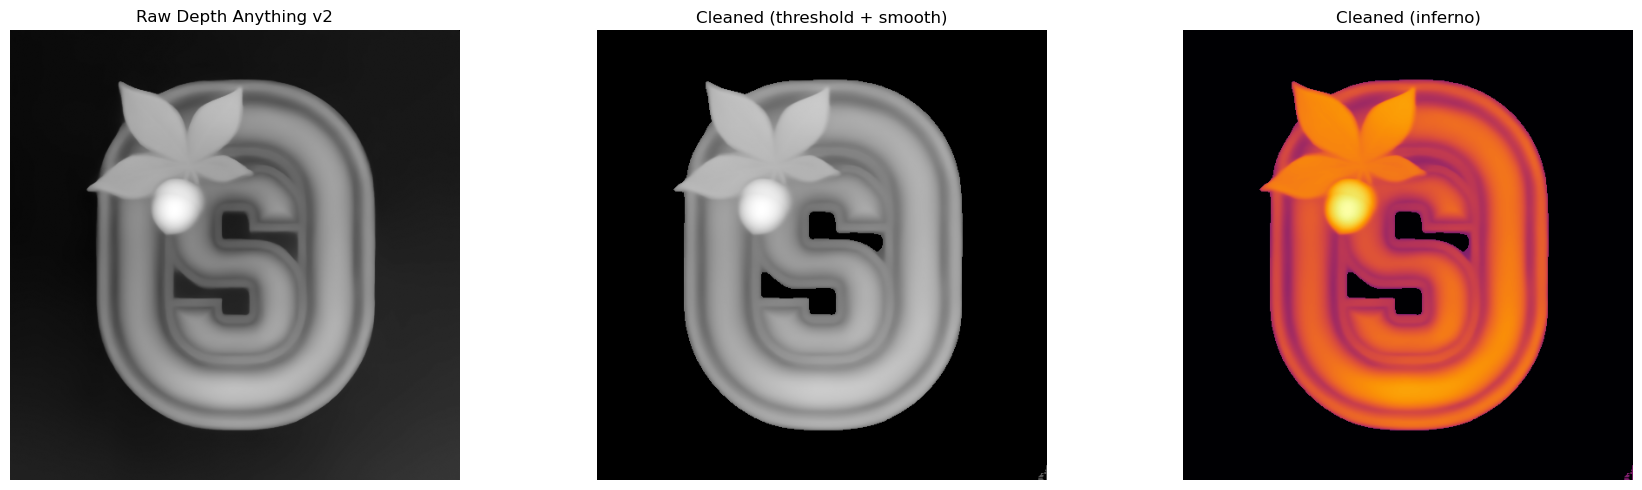

Saved.


In [25]:
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# Your existing Depth Anything output (already normalized 0-1)
depth = depth_normalized.squeeze().numpy()

# Step 1: Threshold background to pure black
threshold = 0.21# lowered slightly to preserve more subject
depth_clean = depth.copy()
depth_clean[depth_clean < threshold] = 0

# Step 2: Smooth only the subject, preserve edges
mask = depth_clean > 0
depth_smooth = depth_clean.copy()
depth_smooth[mask] = gaussian_filter(depth_clean[mask], sigma=1.0)

# Step 3: Normalize subject back to 0.35-1.0 range (like Gemini)
if mask.sum() > 0:
    subject_min = depth_smooth[mask].min()
    subject_max = depth_smooth[mask].max()
    depth_smooth[mask] = 0.35 + (depth_smooth[mask] - subject_min) / (subject_max - subject_min) * 0.65

# Step 4: Compare
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(depth, cmap='gray')
axes[0].set_title("Raw Depth Anything v2")
axes[0].axis('off')

axes[1].imshow(depth_smooth, cmap='gray')
axes[1].set_title("Cleaned (threshold + smooth)")
axes[1].axis('off')

axes[2].imshow(depth_smooth, cmap='inferno')
axes[2].set_title("Cleaned (inferno)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save
result = Image.fromarray((depth_smooth * 255).astype('uint8'))
result.save("depth_anything_v2_cleaned_v2.png")
print("Saved.")